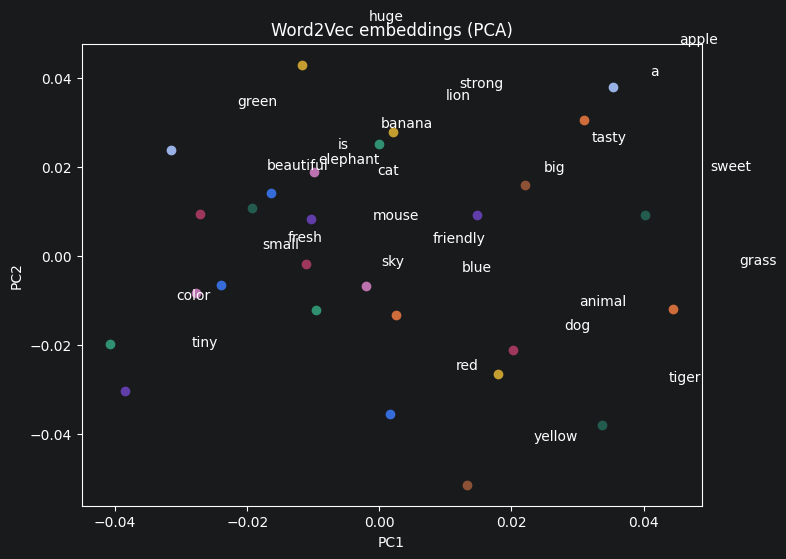

In [2]:
# Zadanie 5 - Wizualizacja embeddingów

"""
Wytrenuj model Word2Vec na prostym korpusie (np. 20 zdan o zwierzetach, kolorach, rozmiarach).
Zwizualizuj embeddingi za pomoca PCA (2D).
Sprawdz czy semantycznie podobne slowa sa blisko siebie.

Oczekiwany wynik: wykres PCA z pogrupowanymi slowami
"""

from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# Korpus (prosty)
# =========================
sentences = [
    "dog is a friendly animal",
    "cat is a small animal",
    "elephant is a big animal",
    "lion is a strong animal",
    "tiger is a strong animal",
    "mouse is a small animal",
    "blue is a color",
    "red is a color",
    "green is a color",
    "yellow is a color",
    "dog is big",
    "cat is small",
    "elephant is huge",
    "lion is big",
    "mouse is tiny",
    "blue sky is beautiful",
    "green grass is fresh",
    "red apple is tasty",
    "yellow banana is sweet",
    "big elephant is strong"
]

# tokenizacja
tokenized = [s.lower().split() for s in sentences]

# =========================
# Word2Vec
# =========================
model = Word2Vec(
    sentences=tokenized,
    vector_size=50,
    window=3,
    min_count=1,
    workers=1
)

# =========================
# PCA
# =========================
words = list(model.wv.index_to_key)
vectors = model.wv[words]

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

# =========================
# Wykres
# =========================
plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    plt.scatter(reduced[i,0], reduced[i,1])
    plt.text(reduced[i,0]+0.01, reduced[i,1]+0.01, word)

plt.title("Word2Vec embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

I0000 00:00:1776955438.439053   17744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776955438.497533   17744 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776955440.147813   17744 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/wojtek/PycharmProjects/my_first_ds_project/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Podobne do 'good':
[('bad', 0.7614331841468811), ('great', 0.7186070680618286), ('decent', 0.7093814611434937), ('nice', 0.6353343725204468), ('fine', 0.6331897377967834)]

Podobne do 'bad':
[('good', 0.7614331245422363), ('terrible', 0.7486379146575928), ('awful', 0.717740535736084), ('horrible', 0.6970925331115723), ('stupid', 0.6764960289001465)]
[('performer', 0.6360100507736206), ('actress', 0.6279047727584839), ('role', 0.5936625003814697), ('comedian', 0.575759768486023), ('filmmaker', 0.5571303963661194)]


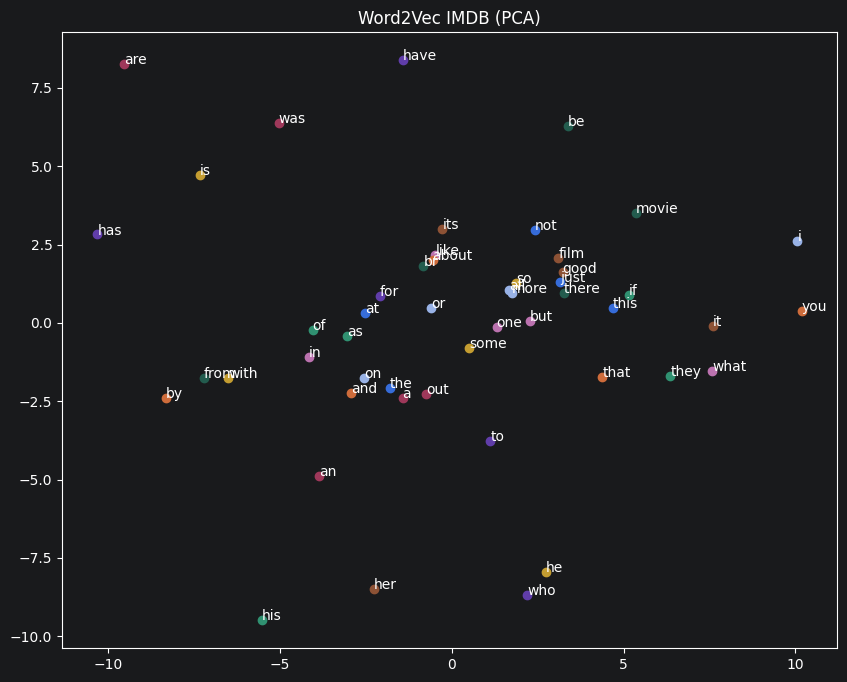

In [3]:
# Zadanie 10 - Word2Vec na prawdziwych danych
"""
Wytrenuj Word2Vec na IMDB dataset (50k recenzji):
Przygotuj dane: tokenizacja, lowercase, usuniecie interpunkcji
Wytrenuj model (vector_size=100, window=5)
Przetestuj analogie i podobienstwa
Zwizualizuj 50 najczestszych slow (PCA/t-SNE

Oczekiwany wynik: wytrenowany model z wizualizacja
"""

import re
from tensorflow.keras.datasets import imdb

# load (indeksy → słowa)
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded])

(x_train, _), _ = imdb.load_data(num_words=10000)

texts = [decode_review(x) for x in x_train]

# =========================
# preprocessing
# =========================
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text.split()

tokenized = [preprocess(t) for t in texts]

from gensim.models import Word2Vec

model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

print("Podobne do 'good':")
print(model.wv.most_similar("good", topn=5))

print("\nPodobne do 'bad':")
print(model.wv.most_similar("bad", topn=5))

print(model.wv.most_similar(
    positive=["good", "actor"],
    negative=["bad"],
    topn=5
))

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from collections import Counter

# najczęstsze słowa
all_words = [w for sent in tokenized for w in sent]
common_words = [w for w, _ in Counter(all_words).most_common(50)]

vectors = np.array([model.wv[w] for w in common_words if w in model.wv])

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(10,8))

for i, word in enumerate(common_words):
    if word in model.wv:
        plt.scatter(reduced[i,0], reduced[i,1])
        plt.text(reduced[i,0], reduced[i,1], word)

plt.title("Word2Vec IMDB (PCA)")
plt.show()